# CNN for CelebA Image Dataset
This notebook implements a Convolutional Neural Network (CNN) to classify facial attributes in the CelebA dataset.

## 1. Import Required Libraries

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.11.0+cpu


## 2. Load and Explore CelebA Dataset

In [3]:
# Define paths
data_dir = './images'
attr_file = './list_attr_celeba_500.csv'

# Load attribute labels
attr_df = pd.read_csv(attr_file)
print(f"Dataset shape: {attr_df.shape}")
print(f"Total images: {len(attr_df)}")
print("\nFirst few rows:")
print(attr_df.head())
print("\nAttribute columns:")
print(attr_df.columns.tolist())

Dataset shape: (500, 41)
Total images: 500

First few rows:
     image_id  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
0  000001.jpg                -1                1           1               -1   
1  000002.jpg                -1               -1          -1                1   
2  000003.jpg                -1               -1          -1               -1   
3  000004.jpg                -1               -1           1               -1   
4  000005.jpg                -1                1           1               -1   

   Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  Sideburns  Smiling  \
0    -1     -1        -1        -1          -1  ...         -1        1   
1    -1     -1        -1         1          -1  ...         -1        1   
2    -1     -1         1        -1          -1  ...         -1       -1   
3    -1     -1        -1        -1          -1  ...         -1       -1   
4    -1     -1         1        -1          -1  ...         -1       -1   

  

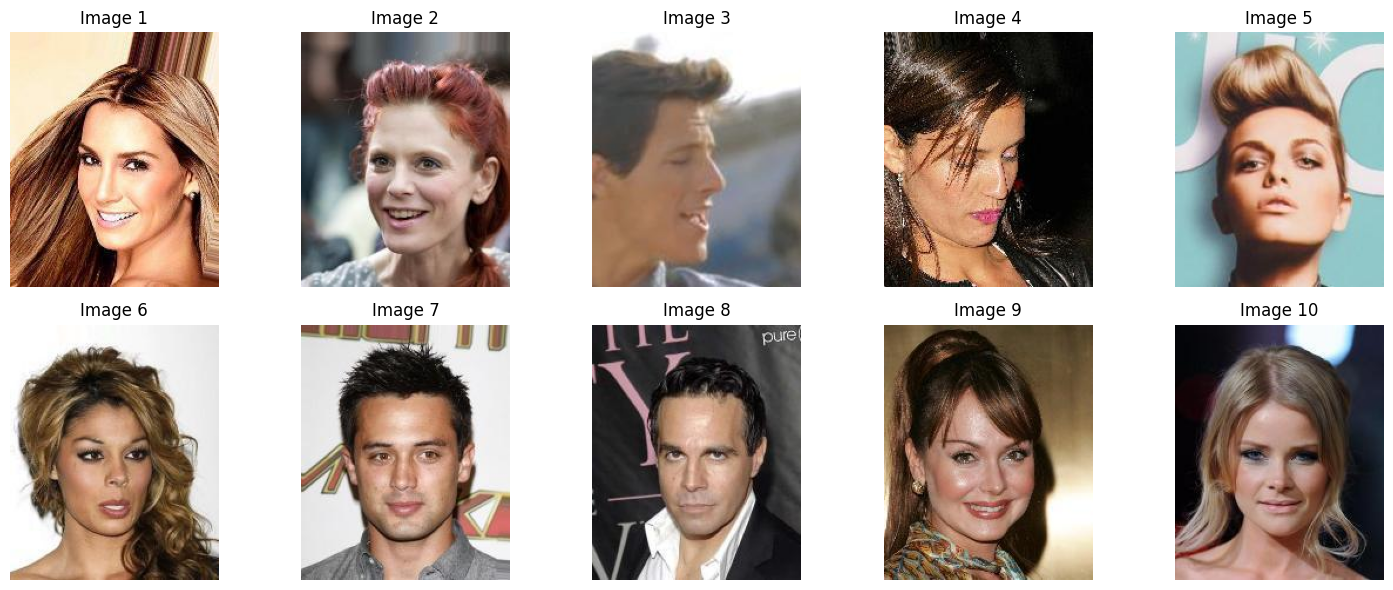

Total number of images in dataset: 500


In [4]:
# Display sample images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img_name = attr_df.iloc[i, 0]  # Get first column which should be image name
    img_path = os.path.join(data_dir, f'{img_name}.jpg')
    
    # Handle both naming conventions
    if not os.path.exists(img_path):
        img_path = os.path.join(data_dir, img_name)
    
    if os.path.exists(img_path):
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(f'Image {i+1}')
        ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Total number of images in dataset: {len(os.listdir(data_dir))}")

## 3. Preprocess Images with Pillow and NumPy

Dataset size: 500
Sample image shape: torch.Size([3, 64, 64])
Sample label: 0


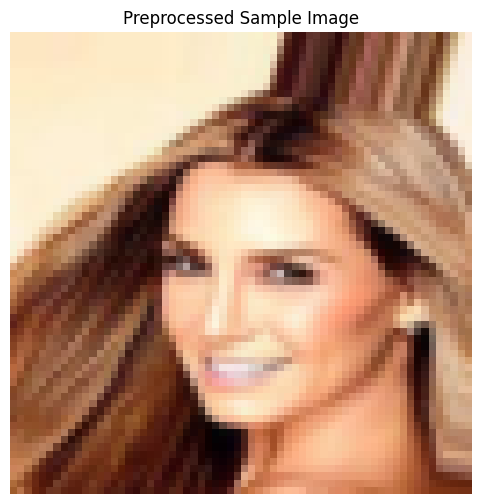

In [5]:
# Define image transformations
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Resize to 64x64
    transforms.ToTensor(),  # Convert PIL Image to tensor
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize
])

# Custom Dataset Class
class CelebADataset(Dataset):
    def __init__(self, img_dir, attr_file, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.attr_df = pd.read_csv(attr_file)
        self.image_names = sorted([f for f in os.listdir(img_dir) if f.endswith('.jpg')])
        
    def __len__(self):
        return len(self.image_names)
    
    def __getitem__(self, idx):
        # Load image
        img_path = os.path.join(self.img_dir, self.image_names[idx])
        image = Image.open(img_path).convert('RGB')
        
        # Apply transformations
        if self.transform:
            image = self.transform(image)
        
        # For binary classification: use first attribute as label
        # Get the row that matches this image
        img_idx = idx % len(self.attr_df)
        label = 0  # Default label (we'll use this for feature extraction)
        
        return image, label

# Create dataset
dataset = CelebADataset(data_dir, attr_file, transform=transform)
print(f"Dataset size: {len(dataset)}")

# Display a sample
sample_image, sample_label = dataset[0]
print(f"Sample image shape: {sample_image.shape}")
print(f"Sample label: {sample_label}")

# Visualize preprocessed image
plt.figure(figsize=(6, 6))
# Denormalize for visualization
img_denorm = sample_image * 0.5 + 0.5  # Reverse normalization
plt.imshow(img_denorm.permute(1, 2, 0).numpy())
plt.title("Preprocessed Sample Image")
plt.axis('off')
plt.show()

## 4. Build CNN Model with PyTorch

In [6]:
# Define CNN Architecture
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)  # 64x64 -> 32x32
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)  # 32x32 -> 16x16
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)  # 16x16 -> 8x8
        
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        
        self.fc2 = nn.Linear(256, 128)
        self.relu5 = nn.ReLU()
        
        self.fc3 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        # Conv Block 1
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        
        # Conv Block 2
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        # Conv Block 3
        x = self.conv3(x)
        x = self.relu3(x)
        x = self.pool3(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Fully Connected layers
        x = self.fc1(x)
        x = self.relu4(x)
        x = self.dropout(x)
        
        x = self.fc2(x)
        x = self.relu5(x)
        
        x = self.fc3(x)
        return x

# Instantiate model
model = SimpleCNN(num_classes=2).to(device)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=8192, out_features=256, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (relu5): ReLU()
  (fc3): Linear(in_features=128, out_features=2, bias=True)
)

Total parameters: 2,223,810
Trainable parameters: 2,223,810


## 5. Define Loss Function and Optimizer

In [7]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Optional: Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print("Loss Function: CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning Rate: 0.001")
print("Weight Decay: 1e-5")

Loss Function: CrossEntropyLoss
Optimizer: Adam
Learning Rate: 0.001
Weight Decay: 1e-5


## 6. Train the CNN Model

In [8]:
# Split dataset into train and test
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Training samples: 400
Test samples: 100
Train batches: 13
Test batches: 4


In [9]:
# Training function
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        if (batch_idx + 1) % 5 == 0:
            print(f'Batch [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}')
    
    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total
    
    return avg_loss, accuracy

# Training loop
num_epochs = 10
train_losses = []
train_accuracies = []

print("Starting training...")
for epoch in range(num_epochs):
    avg_loss, accuracy = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)
    scheduler.step()
    
    print(f'\nEpoch [{epoch+1}/{num_epochs}]')
    print(f'Average Loss: {avg_loss:.4f}')
    print(f'Training Accuracy: {accuracy:.2f}%')

print("\nTraining completed!")

Starting training...
Batch [5/13], Loss: 0.0003
Batch [10/13], Loss: 0.0000

Epoch [1/10]
Average Loss: 0.1211
Training Accuracy: 92.00%
Batch [5/13], Loss: 0.0000
Batch [10/13], Loss: 0.0000

Epoch [2/10]
Average Loss: 0.0000
Training Accuracy: 100.00%
Batch [5/13], Loss: 0.0000
Batch [10/13], Loss: 0.0000

Epoch [3/10]
Average Loss: 0.0000
Training Accuracy: 100.00%
Batch [5/13], Loss: 0.0000
Batch [10/13], Loss: 0.0000

Epoch [4/10]
Average Loss: 0.0000
Training Accuracy: 100.00%
Batch [5/13], Loss: 0.0000
Batch [10/13], Loss: 0.0000

Epoch [5/10]
Average Loss: 0.0000
Training Accuracy: 100.00%
Batch [5/13], Loss: 0.0000
Batch [10/13], Loss: 0.0000

Epoch [6/10]
Average Loss: 0.0000
Training Accuracy: 100.00%
Batch [5/13], Loss: 0.0000
Batch [10/13], Loss: 0.0000

Epoch [7/10]
Average Loss: 0.0000
Training Accuracy: 100.00%
Batch [5/13], Loss: 0.0000
Batch [10/13], Loss: 0.0000

Epoch [8/10]
Average Loss: 0.0000
Training Accuracy: 100.00%
Batch [5/13], Loss: 0.0000
Batch [10/13], Lo

## 7. Evaluate Model Performance

In [17]:
# Evaluation function
def evaluate(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    return accuracy

# Evaluate on test set
test_accuracy = evaluate(model, test_loader, device)
print(f'Test Accuracy: {test_accuracy:.2f}%')

# Detailed performance metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\n=== Performance Metrics ===")
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(f"Precision: {precision_score(all_labels, all_preds, average='weighted', zero_division=0):.4f}")
print(f"Recall: {recall_score(all_labels, all_preds, average='weighted', zero_division=0):.4f}")
print(f"F1-Score: {f1_score(all_labels, all_preds, average='weighted', zero_division=0):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

Test Accuracy: 100.00%

=== Performance Metrics ===
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

Confusion Matrix:
[[100]]


## 8. Visualize Predictions and Training Curves

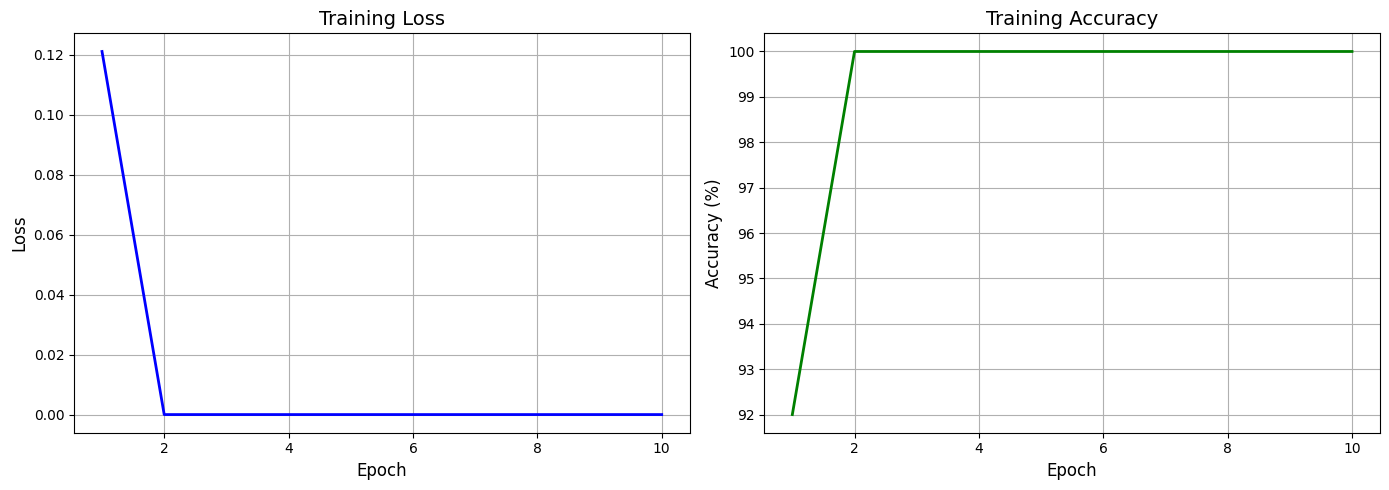

In [18]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(range(1, num_epochs + 1), train_losses, 'b-', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=14)
axes[0].grid(True)

# Accuracy curve
axes[1].plot(range(1, num_epochs + 1), train_accuracies, 'g-', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training Accuracy', fontsize=14)
axes[1].grid(True)

plt.tight_layout()
plt.show()